In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from sklearn.metrics.pairwise import cosine_similarity

seed = 42
rng = np.random.default_rng(seed)

In [18]:
exc_fname = Path("/src/project/data/experiment/exc_images_preprocessed.npy")
exc_images = np.load(exc_fname)
print(exc_images.shape)

(960, 36, 36)


In [19]:
exc_images_mean = exc_images.mean(axis=0)
exc_images = exc_images - exc_images_mean
vmin = np.min(exc_images)
vmax = np.max(exc_images)

Text(0.5, 1.0, 'Cosine sim between exc stimuli after centering')

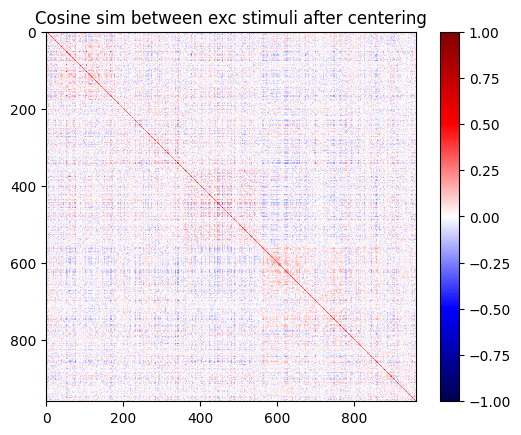

In [20]:
csim_centered = cosine_similarity(exc_images.reshape(exc_images.shape[0], -1))
fig, ax = plt.subplots()
im = ax.imshow(csim_centered, cmap="seismic", vmin=-1, vmax=1)
# plot a colorbar to show the correspondence between values and colors
plt.colorbar(im, ax=ax)
plt.title("Cosine sim between exc stimuli after centering")

In [27]:
indices = np.where((0.01 < csim_centered) & (csim_centered < 0.1))

In [28]:
len(indices[0])

188130

0 1


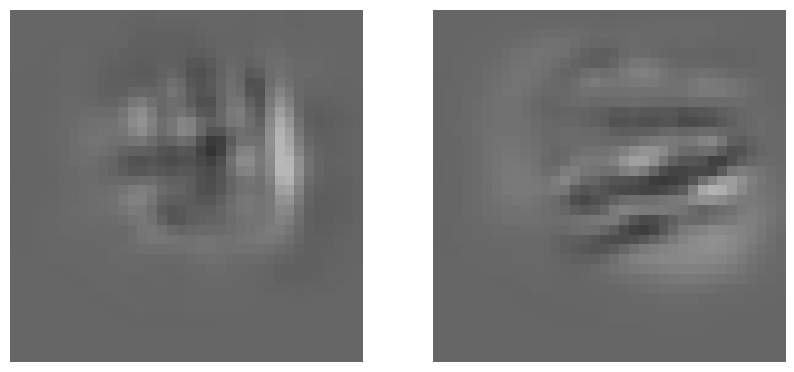

0 2


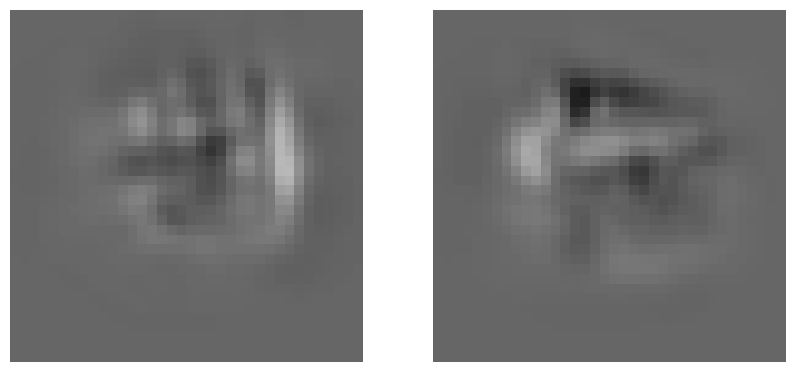

0 7


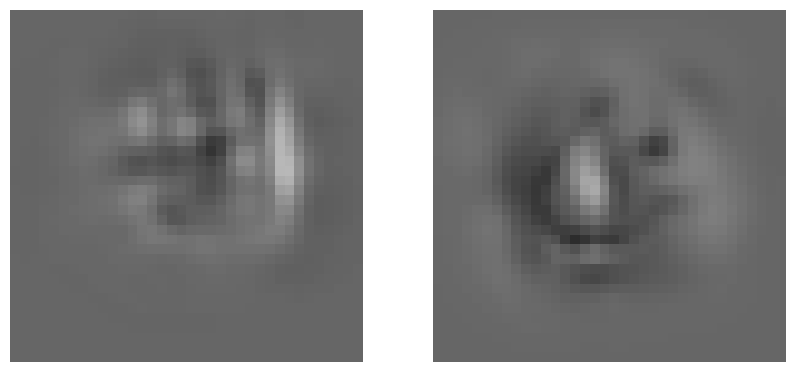

0 15


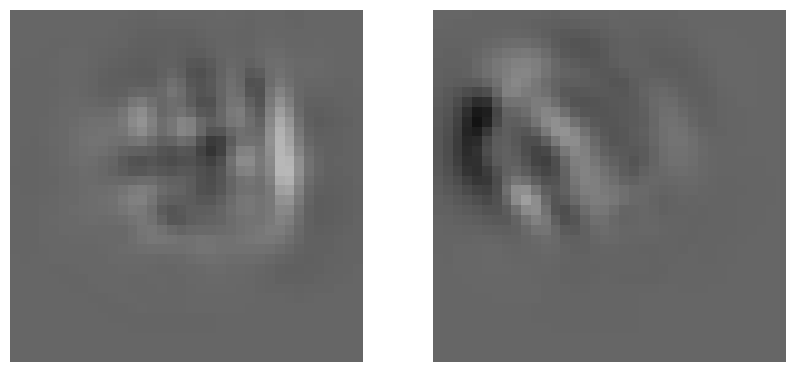

0 18


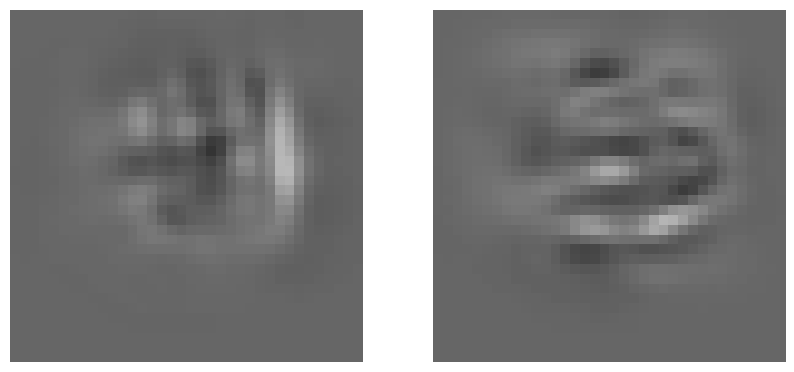

0 27


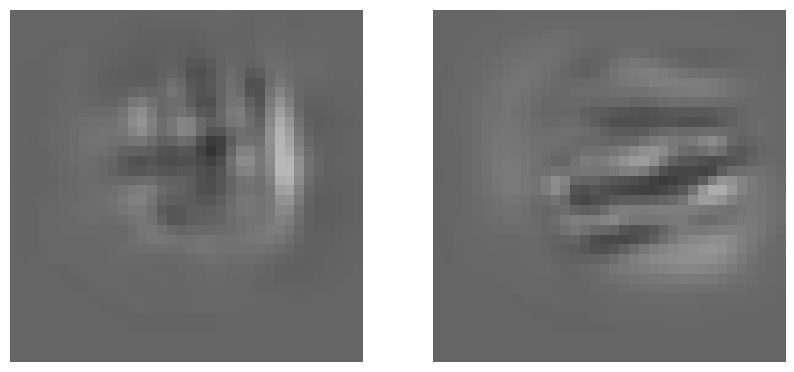

In [29]:
for idx, (i, j) in enumerate(zip(indices[0], indices[1])):
    if idx > 5:
        break
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    print(i, j)
    ax[0].imshow(exc_images[i], cmap="gray", vmin=vmin, vmax=vmax)
    ax[1].imshow(exc_images[j], cmap="gray", vmin=vmin, vmax=vmax)
    ax[0].axis("off")
    ax[1].axis("off")
    plt.show()